# Tech Challenge — Fase 1: Maternal Health Risk

## Objetivo

Aplicar o **mesmo pipeline de ML** do notebook `01_eda_modelagem.ipynb` (SIASI) a um segundo dataset público de saúde da mulher: **Maternal Health Risk** (UCI/Kaggle) — um dos datasets sugeridos no enunciado do desafio.

**Dataset**: 1.014 gestantes de zonas rurais de Bangladesh, monitoradas via dispositivos IoT.
Fonte: https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data

| Coluna original | Renomeada | Significado |
|---|---|---|
| Age | `idade` | Idade da gestante (anos) |
| SystolicBP | `pressao_sistolica` | Pressão arterial sistólica (mmHg) |
| DiastolicBP | `pressao_diastolica` | Pressão arterial diastólica (mmHg) |
| BS | `glicemia` | Glicose sanguínea (mmol/L) |
| BodyTemp | `temperatura_corporal` | Temperatura corporal (°F) |
| HeartRate | `frequencia_cardiaca` | Frequência cardíaca (bpm) |
| RiskLevel | *(alvo)* | Nível de risco: low / mid / high |

**Diferenças estruturais em relação ao SIASI**: aqui cada linha é **uma gestante** (não uma consulta), então não há necessidade de split por grupo; as features já são **medidas clínicas numéricas** (não há datas para derivar); e o alvo tem **3 classes ordenadas** em vez de 2.

> ⚠️ **Aviso ético**: este modelo é um **suporte à decisão** e não substitui avaliação médica profissional. O médico sempre deve ter a palavra final no diagnóstico.

## 1. Configuração

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)

TARGET_COL   = "RiskLevel"
DATA_PATH    = Path("..") / "data" / "maternal_risk" / "raw" / "maternal_health_risk_data_set.csv"
PROCESSED_DIR = Path("..") / "data" / "maternal_risk" / "processed"
FIGURES_DIR  = Path("..") / "reports" / "figures"
METRICS_DIR  = Path("..") / "reports" / "metrics"
RANDOM_STATE = 42
TEST_SIZE    = 0.2
ORDEM_RISCO  = ["low risk", "mid risk", "high risk"]

print(f"Alvo    : {TARGET_COL}")
print(f"Arquivo : {DATA_PATH.name}")

Alvo    : RiskLevel
Arquivo : maternal_health_risk_data_set.csv


## 2. Carregamento dos Dados

In [2]:
RENAME_MAP = {
    "Age": "idade",
    "SystolicBP": "pressao_sistolica",
    "DiastolicBP": "pressao_diastolica",
    "BS": "glicemia",
    "BodyTemp": "temperatura_corporal",
    "HeartRate": "frequencia_cardiaca",
}
df = pd.read_csv(DATA_PATH).rename(columns=RENAME_MAP)
print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado: 1014 linhas x 7 colunas


,idade,pressao_sistolica,pressao_diastolica,glicemia,temperatura_corporal,frequencia_cardiaca,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
from data_loader import basic_validation

report = basic_validation(df)
# Observação conhecida deste dataset: há linhas duplicadas (medições idênticas de
# gestantes diferentes ou repetidas). Mantemos as linhas por não haver identificador
# de paciente que permita distingui-las — limitação discutida na conclusão.


=== Validação básica ===
Shape       : (1014, 7)
Duplicados  : 562
Colunas com missing:
Series([], dtype: float64)


## 3. Análise Exploratória de Dados (EDA)

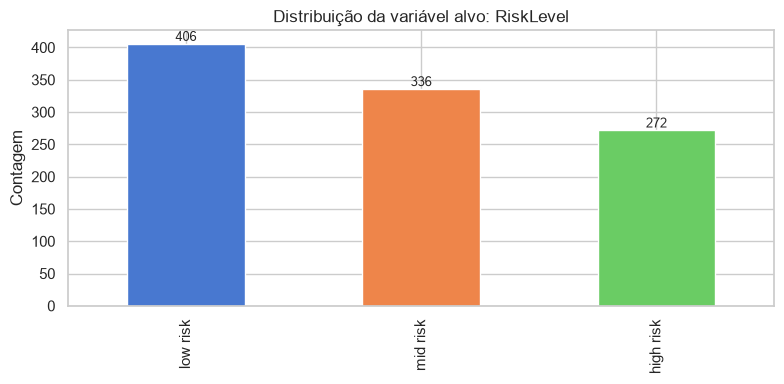


Proporção (%):
RiskLevel
low risk     40.04
mid risk     33.14
high risk    26.82


In [4]:
# Distribuição da variável alvo
fig, ax = plt.subplots(figsize=(8, 4))
vc = df[TARGET_COL].value_counts().reindex(ORDEM_RISCO)
vc.plot(kind="bar", ax=ax, color=sns.color_palette("muted"))
ax.set_title(f"Distribuição da variável alvo: {TARGET_COL}")
ax.set_xlabel("")
ax.set_ylabel("Contagem")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mr_target_distribution.png", dpi=150)
plt.show()
print("\nProporção (%):")
print((vc / len(df) * 100).round(2).to_string())

In [5]:
print("Estatísticas descritivas:")
df.describe().T

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
idade,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
pressao_sistolica,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
pressao_diastolica,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
glicemia,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
temperatura_corporal,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
frequencia_cardiaca,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


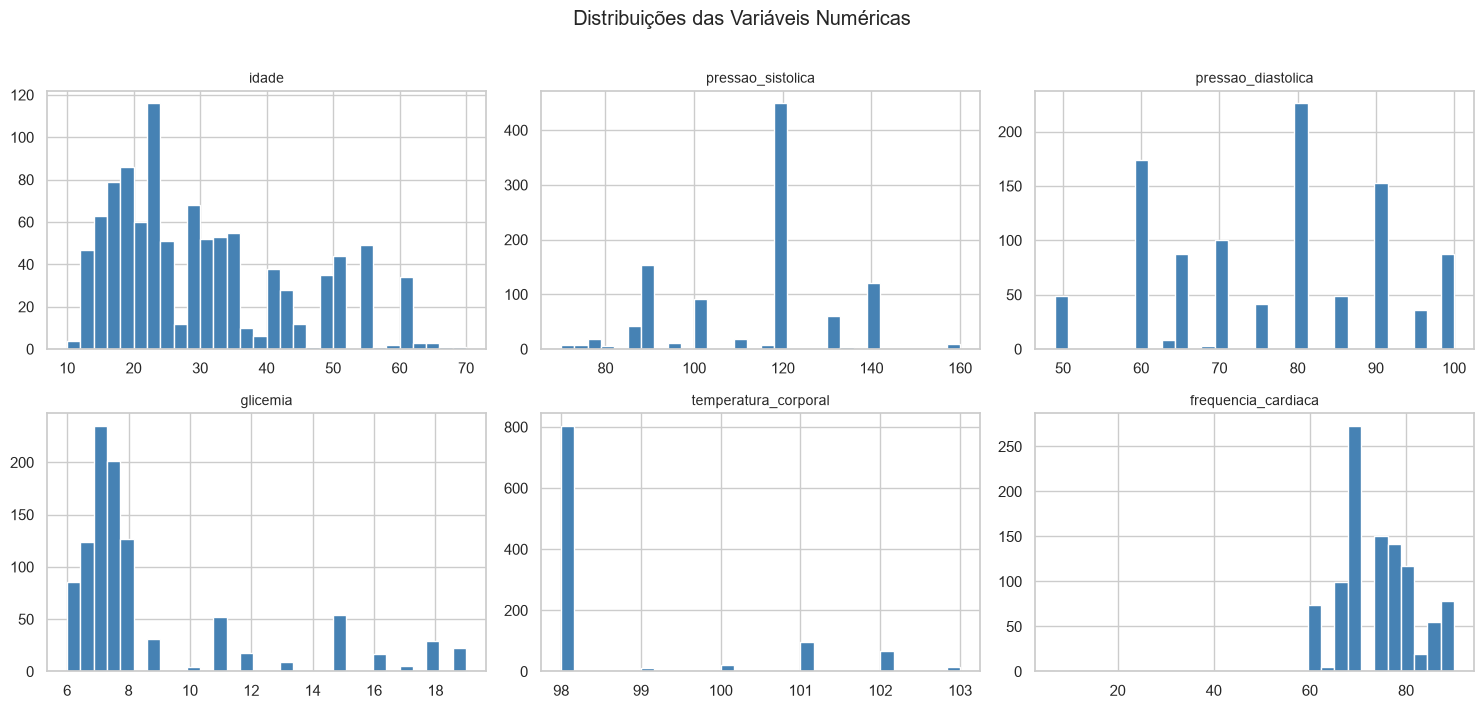

In [6]:
# Distribuições das variáveis numéricas
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(ax=ax, bins=30, edgecolor="white", color="steelblue")
    ax.set_title(col, fontsize=10)
plt.suptitle("Distribuições das Variáveis Numéricas", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mr_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

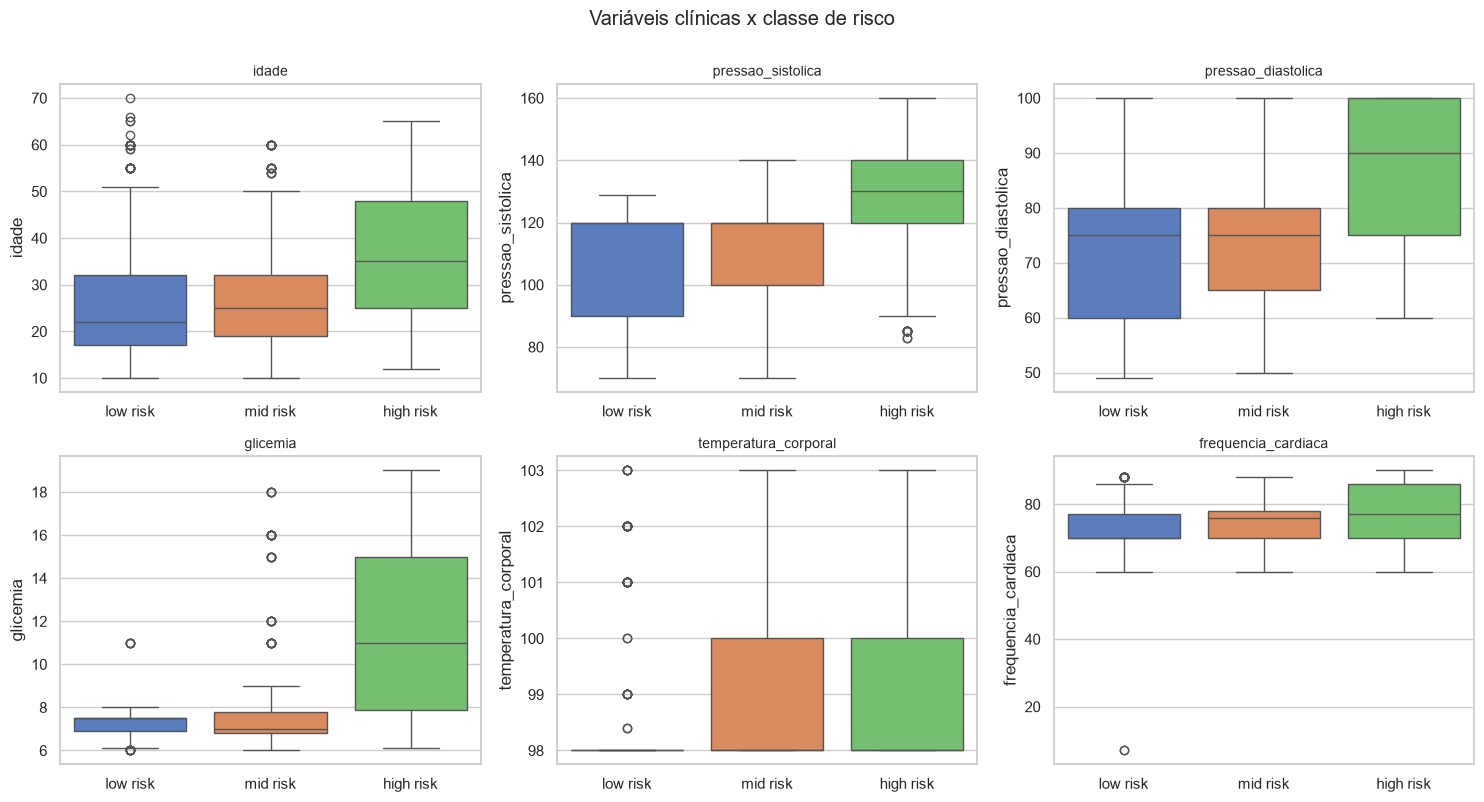

In [7]:
# Distribuição de cada variável por classe de risco
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=ax, order=ORDEM_RISCO, palette="muted")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Variáveis clínicas x classe de risco", y=1.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mr_features_by_risk.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Análise de Correlação

Diferentemente do SIASI, aqui **todas** as features já são medidas clínicas numéricas — a matriz de correlação é informativa desde o início. Como o alvo é **ordinal** (low < mid < high), ele entra codificado como `risco_ordinal` (0/1/2).

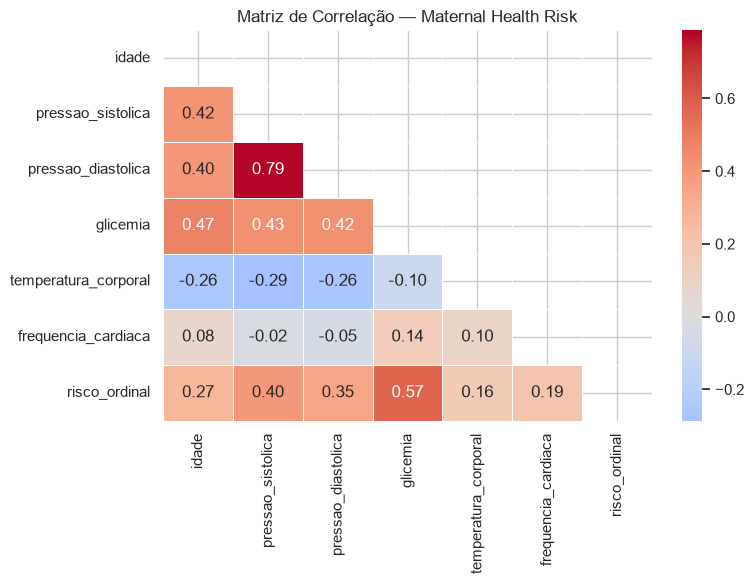

Correlação de cada feature com o alvo (risco_ordinal), da mais forte à mais fraca:
glicemia                0.570
pressao_sistolica       0.396
pressao_diastolica      0.347
idade                   0.267
frequencia_cardiaca     0.194
temperatura_corporal    0.164


In [8]:
df_corr = df.copy()
df_corr["risco_ordinal"] = df_corr[TARGET_COL].map({r: i for i, r in enumerate(ORDEM_RISCO)})

corr = df_corr.select_dtypes(include=["number"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Matriz de Correlação — Maternal Health Risk")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mr_correlation_matrix.png", dpi=150)
plt.show()

print("Correlação de cada feature com o alvo (risco_ordinal), da mais forte à mais fraca:")
print(corr["risco_ordinal"].drop("risco_ordinal").sort_values(key=abs, ascending=False).round(3).to_string())

## 5. Pré-processamento

Sem features derivadas a criar (as variáveis já são clínicas) e sem risco de vazamento por grupo: **cada linha é uma gestante**, então o `train_test_split` estratificado é suficiente — a estratificação preserva a proporção das 3 classes nos dois conjuntos. O dataset tratado (colunas renomeadas + alvo ordinal) é exportado para `data/maternal_risk/processed/`.

In [9]:
from sklearn.model_selection import train_test_split
from preprocess import build_preprocessor, get_feature_names

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print(f"Classes no teste (%):")
print((y_test.value_counts(normalize=True) * 100).round(1).to_string())

# Exporta o dataset tratado
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_csv = PROCESSED_DIR / "maternal_risk_tratado.csv"
df_corr.to_csv(out_csv, index=False, encoding="utf-8")
print(f"\nCSV tratado salvo em: {out_csv.resolve()}")

Treino: 811 | Teste: 203
Classes no teste (%):
RiskLevel
low risk     39.9
mid risk     33.0
high risk    27.1

CSV tratado salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\data\maternal_risk\processed\maternal_risk_tratado.csv


## 6. Treinamento dos Modelos

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

models = {
    "MaternalRisk_LogisticRegression": Pipeline([
        ("prep", build_preprocessor(X_train)),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "MaternalRisk_DecisionTree": Pipeline([
        ("prep", build_preprocessor(X_train)),
        ("model", DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

trained_models = {}
for name, pipeline in models.items():
    print(f"Treinando {name}...")
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(f"  ok.")

[preprocess] Numéricas : 6 colunas
[preprocess] Categóricas: 0 colunas
[preprocess] Numéricas : 6 colunas
[preprocess] Categóricas: 0 colunas
Treinando MaternalRisk_LogisticRegression...
  ok.
Treinando MaternalRisk_DecisionTree...
  ok.


## 7. Avaliação dos Modelos

In [11]:
from evaluate import evaluate_model

all_metrics = []
for name, pipeline in trained_models.items():
    metrics = evaluate_model(name, pipeline, X_test, y_test, save=True)
    all_metrics.append(metrics)


Modelo : MaternalRisk_LogisticRegression
              precision    recall  f1-score   support

   high risk      0.710     0.800     0.752        55
    low risk      0.618     0.679     0.647        81
    mid risk      0.442     0.343     0.387        67

    accuracy                          0.601       203
   macro avg      0.590     0.607     0.595       203
weighted avg      0.585     0.601     0.590       203

Accuracy : 0.601
Recall   : 0.601
F1-score : 0.5895
Métricas salvas em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\metrics\MaternalRisk_LogisticRegression_metrics.json


Matriz de confusão salva em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\MaternalRisk_LogisticRegression_confusion_matrix.png



Modelo : MaternalRisk_DecisionTree
              precision    recall  f1-score   support

   high risk      0.887     0.855     0.870        55
    low risk      0.619     0.901     0.734        81
    mid risk      0.594     0.284     0.384        67

    accuracy                          0.685       203
   macro avg      0.700     0.680     0.663       203
weighted avg      0.683     0.685     0.655       203

Accuracy : 0.6847
Recall   : 0.6847
F1-score : 0.6552
Métricas salvas em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\metrics\MaternalRisk_DecisionTree_metrics.json


Matriz de confusão salva em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\MaternalRisk_DecisionTree_confusion_matrix.png


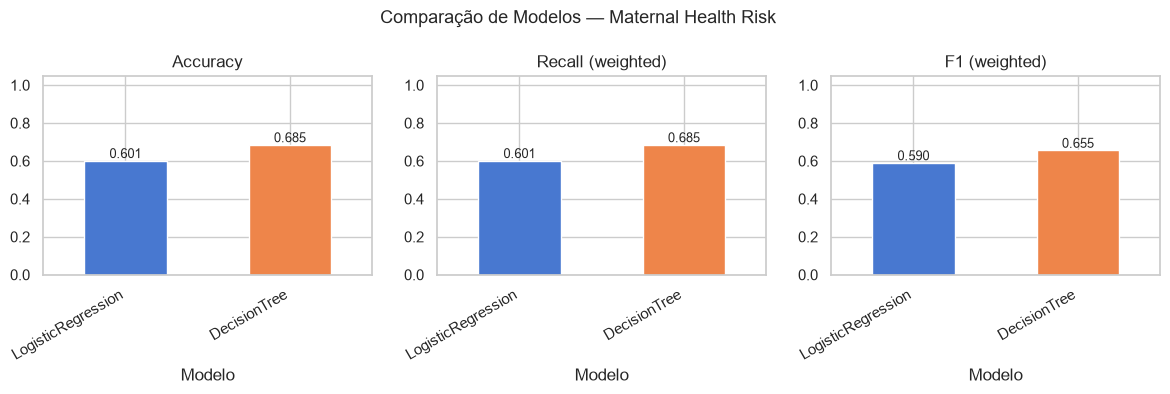

,Accuracy,Recall (weighted),F1 (weighted)
Modelo,,,
LogisticRegression,0.6010,0.6010,0.5895
DecisionTree,0.6847,0.6847,0.6552


In [12]:
df_comparison = pd.DataFrame([
    {"Modelo": m["model"].replace("MaternalRisk_", ""),
     "Accuracy": m["accuracy"],
     "Recall (weighted)": m["recall_weighted"],
     "F1 (weighted)": m["f1_weighted"]}
    for m in all_metrics
]).set_index("Modelo")
df_comparison.to_csv(METRICS_DIR / "mr_models_comparison.csv")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, ["Accuracy", "Recall (weighted)", "F1 (weighted)"]):
    df_comparison[metric].plot(kind="bar", ax=ax, color=sns.color_palette("muted"), edgecolor="white")
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(df_comparison.index, rotation=30, ha="right")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Comparação de Modelos — Maternal Health Risk", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mr_models_comparison.png", dpi=150)
plt.show()

df_comparison

## 8. Explicabilidade

### 8.1 Feature Importance (Árvore de Decisão)

In [13]:
from explain import plot_feature_importance

for name, pipeline in trained_models.items():
    prep = pipeline.named_steps["prep"]
    fn = get_feature_names(prep, X_train)
    plot_feature_importance(name, pipeline, feature_names=fn)

[explain] MaternalRisk_LogisticRegression não possui feature_importances_. Pulando.
Feature importance salva em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\MaternalRisk_DecisionTree_feature_importance.png


### 8.2 SHAP — Explicabilidade Global e Local

> Nota: como o problema tem 3 classes, os gráficos SHAP abaixo referem-se à **última classe na ordem alfabética** (`mid risk`) — limitação da função utilitária compartilhada. O ranking de variáveis é, na prática, o mesmo entre as classes deste dataset.

In [14]:
from explain import plot_shap

for name, pipeline in trained_models.items():
    prep = pipeline.named_steps["prep"]
    fn = get_feature_names(prep, X_train)
    plot_shap(name, pipeline, X_test, feature_names=fn, max_samples=200)

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP summary salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\MaternalRisk_LogisticRegression_shap_summary.png


SHAP local (waterfall) salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\MaternalRisk_LogisticRegression_shap_local.png


SHAP summary salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\MaternalRisk_DecisionTree_shap_summary.png


SHAP local (waterfall) salvo em: C:\Projetos\IADT-Fase1-Tech-challenge\reports\figures\MaternalRisk_DecisionTree_shap_local.png


## 9. Conclusão

### Resumo dos resultados

| Modelo | Accuracy | Recall high risk | Precision high risk | F1 (weighted) |
|---|---|---|---|---|
| Regressão Logística | 0,601 | 0,800 | 0,710 | 0,590 |
| Árvore de Decisão | **0,685** | **0,855** | **0,887** | **0,655** |

Com 203 gestantes no teste (estratificado), a **Árvore de Decisão** vence em todas as métricas e entrega um desempenho forte na classe que mais importa: identifica **85,5% dos casos de alto risco com 88,7% de precisão** — quando ela alerta "high risk", quase 9 em 10 vezes está certa. É um perfil muito melhor que o do SIASI, e a explicação está nos dados, não no algoritmo.

### Por que este dataset rende mais que o SIASI?

As features aqui são **medidas clínicas diretas** (pressão, glicemia, temperatura, FC), com relação causal conhecida com o risco gestacional — a correlação com o alvo chega a **0,57 (glicemia)** e **0,40 (pressão sistólica)**, contra no máximo 0,09 no SIASI (dados administrativos). A comparação entre os dois notebooks demonstra na prática a lição central do projeto: **a qualidade das features importa mais que o modelo**.

### O ponto fraco: a classe intermediária

O recall de `mid risk` é baixo nos dois modelos (0,28 na árvore): a fronteira entre "risco médio" e as classes vizinhas é clinicamente difusa, e o modelo tende a confundi-las. O erro mais comum é classificar `mid` como `low` — relevante para triagem, pois subestima risco. Vale discutir se, na prática, as classes `mid`+`high` não deveriam ser agrupadas num alerta único.

### Limitações

1. **562 linhas duplicadas** (55% do dataset) sem identificador de paciente: podem ser gestantes diferentes com medições iguais (plausível, dado o arredondamento das medidas) ou repetições — na pior hipótese, duplicatas presentes em treino e teste inflam as métricas. Limitação conhecida deste dataset público.
2. **População específica** (zonas rurais de Bangladesh): generalização para outros contextos exige validação local.
3. **Temperatura em °F** e glicemia em mmol/L — unidades diferentes das usuais no Brasil; conversão necessária em qualquer uso prático.
4. **O médico sempre tem a palavra final** — o modelo é suporte à triagem, não diagnóstico.

### Conexão com o notebook SIASI

Os dois notebooks se complementam no relatório: o SIASI mostra o pipeline em **dados administrativos reais e imperfeitos** (leakage, granularidade por consulta, 14% sem rótulo) e o Maternal Risk mostra o mesmo pipeline em **dados clínicos limpos** — juntos, evidenciam como a natureza dos dados determina o teto de desempenho e quais cuidados metodológicos cada cenário exige.